In [449]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 


In [450]:
df = pd.read_csv('GoogleAds_DataAnalytics_Sales_Uncleaned.csv')

In [451]:
df

,Ad_ID,Campaign_Name,Clicks,Impressions,Cost,Leads,Conversions,Conversion Rate,Sale_Amount,Ad_Date,Location,Device,Keyword
0,A1000,DataAnalyticsCourse,104.0,4498.0,$231.88,14.0,7.0,0.058,$1892,2024-11-16,hyderabad,desktop,learn data analytics
1,A1001,DataAnalyticsCourse,173.0,5107.0,$216.84,10.0,8.0,0.046,$1679,20-11-2024,hyderabad,mobile,data analytics course
2,A1002,Data Anlytics Corse,90.0,4544.0,$203.66,26.0,9.0,NaN,$1624,2024/11/16,hyderabad,Desktop,data analitics online
3,A1003,Data Analytcis Course,142.0,3185.0,$237.66,17.0,6.0,NaN,$1225,2024-11-26,HYDERABAD,tablet,data anaytics training
4,A1004,Data Analytics Corse,156.0,3361.0,$195.9,30.0,8.0,NaN,$1091,2024-11-22,hyderabad,desktop,online data analytic
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2595,A3595,DataAnalyticsCourse,88.0,5344.0,$242.07,17.0,9.0,0.054,$1418,29-11-2024,HYDERABAD,MOBILE,online data analytic
2596,A3596,DataAnalyticsCourse,154.0,3211.0,$248.28,14.0,6.0,0.039,$1950,2024/11/28,hyderabad,TABLET,data analitics online
2597,A3597,Data Anlytics Corse,113.0,3808.0,$233.25,18.0,4.0,0.035,$1085,2024-11-02,Hyderbad,desktop,data anaytics training
2598,A3598,Data Analytics Corse,196.0,5853.0,$220.13,16.0,7.0,0.036,$1558,2024-11-08,hydrebad,Tablet,data anaytics training


In [452]:
## Checking for null values 

In [453]:
df.isna().sum()

Ad_ID                0
Campaign_Name        0
Clicks             112
Impressions         54
Cost                97
Leads               48
Conversions         74
Conversion Rate    626
Sale_Amount        139
Ad_Date              0
Location             0
Device               0
Keyword              0
dtype: int64

In [454]:
## There are total 112 null values in Clicks 
## 54 -> Impressions , 94 --> cost , 48 ->> leads, 74--> Conversions , 626--> Conversion Rate 
## 139 --> Sales_ Amount 

In [455]:
## finding total unique Counts 

In [456]:
df.nunique()

Ad_ID              2600
Campaign_Name         4
Clicks              120
Impressions        1702
Cost               2106
Leads                21
Conversions           8
Conversion Rate     105
Sale_Amount         921
Ad_Date              90
Location              4
Device                9
Keyword               6
dtype: int64

In [457]:
## Extracting the all Campaigns names |

In [458]:
campaign_names = df['Campaign_Name'].unique()

In [459]:
print(campaign_names)

['DataAnalyticsCourse' 'Data Anlytics Corse' 'Data Analytcis Course'
 'Data Analytics Corse']


In [460]:
for i in campaign_names:
    data = pd.DataFrame(df[df['Campaign_Name']==i])
    print(f"{data['Ad_ID'].count()} {i}" )
  

637 DataAnalyticsCourse
636 Data Anlytics Corse
680 Data Analytcis Course
647 Data Analytics Corse


In [461]:
## Total number of unique campaigns run under names 

#637 DataAnalyticsCourse
#636 Data Anlytics Corse
#680 Data Analytcis Course
#647 Data Analytics Corse

In [462]:
## handling the null values 

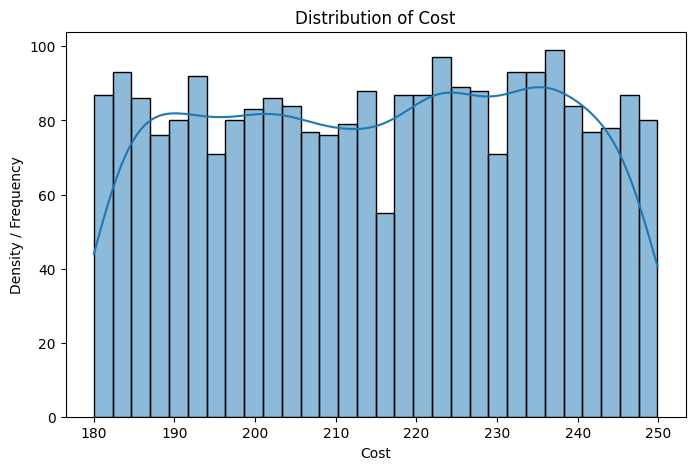

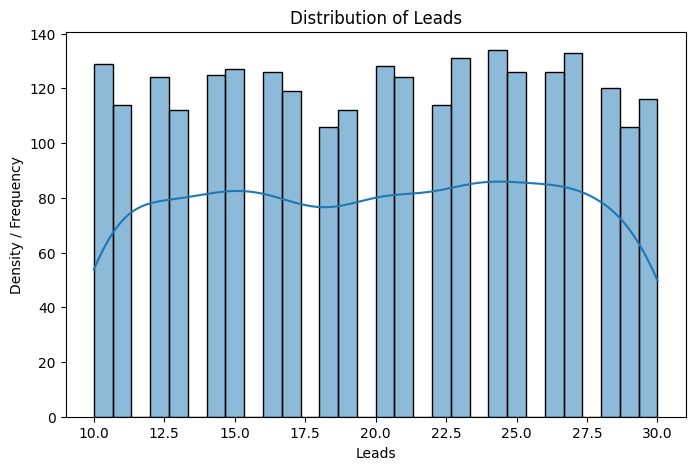

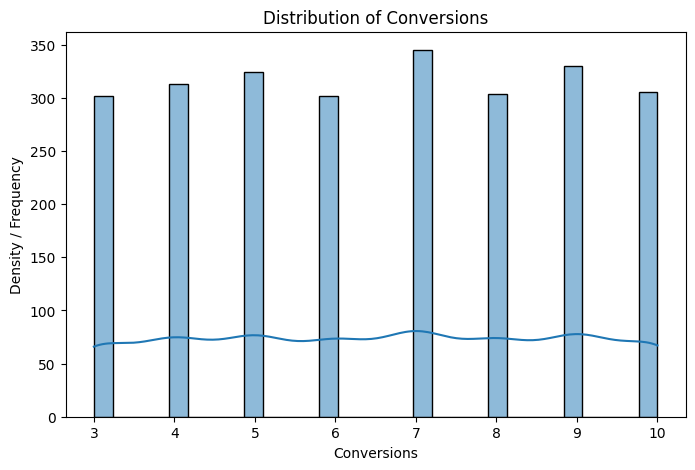

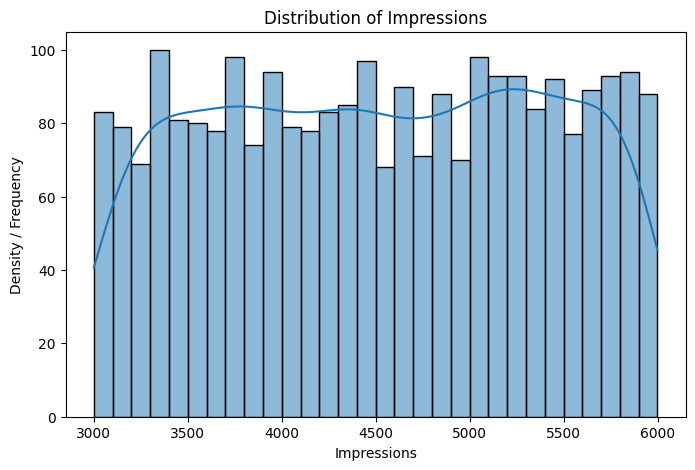

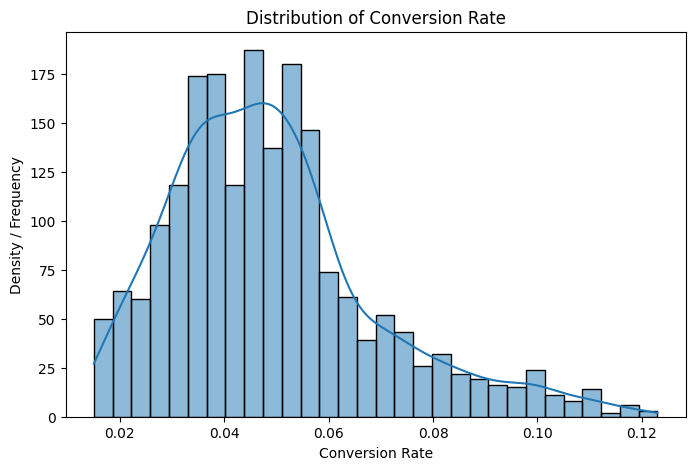

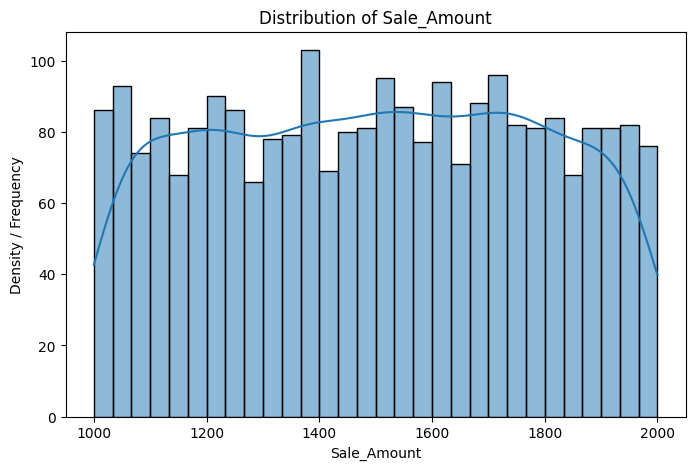

In [463]:
# checking the distribution of data 

cols = [
    "Cost",
    "Leads",
    "Conversions",
    "Impressions",
    "Conversion Rate",
    "Sale_Amount"
]

# Clean currency columns
for col in ["Cost", "Sale_Amount",]:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace("$", "", regex=False)
        .str.replace(",", "", regex=False)
    )

    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )


for col in cols:

    plt.figure(figsize=(8, 5))

    sns.histplot(
        df[col].dropna(),
        kde=True,
        bins=30
    )

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Density / Frequency")

    plt.show()## handling the conversion rate 

In [464]:
## Handling the conversion Rate 

<Axes: xlabel='Conversion Rate', ylabel='Count'>

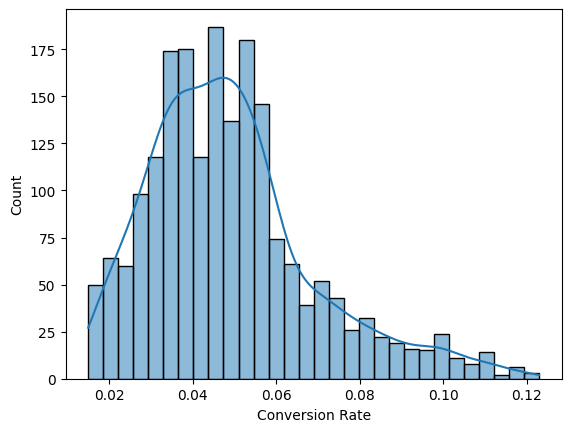

In [465]:

 sns.histplot(
        df["Conversion Rate"],
        kde=True,
        bins=30
    )

In [466]:
df['Conversion Rate'] = df['Conversion Rate'].fillna(df['Conversions']/df['Clicks'])
df['Conversion Rate'] = df['Conversion Rate'].round(3)

In [467]:
df

,Ad_ID,Campaign_Name,Clicks,Impressions,Cost,Leads,Conversions,Conversion Rate,Sale_Amount,Ad_Date,Location,Device,Keyword
0,A1000,DataAnalyticsCourse,104.0,4498.0,231.88,14.0,7.0,0.058,1892.0,2024-11-16,hyderabad,desktop,learn data analytics
1,A1001,DataAnalyticsCourse,173.0,5107.0,216.84,10.0,8.0,0.046,1679.0,20-11-2024,hyderabad,mobile,data analytics course
2,A1002,Data Anlytics Corse,90.0,4544.0,203.66,26.0,9.0,0.100,1624.0,2024/11/16,hyderabad,Desktop,data analitics online
3,A1003,Data Analytcis Course,142.0,3185.0,237.66,17.0,6.0,0.042,1225.0,2024-11-26,HYDERABAD,tablet,data anaytics training
4,A1004,Data Analytics Corse,156.0,3361.0,195.90,30.0,8.0,0.051,1091.0,2024-11-22,hyderabad,desktop,online data analytic
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2595,A3595,DataAnalyticsCourse,88.0,5344.0,242.07,17.0,9.0,0.054,1418.0,29-11-2024,HYDERABAD,MOBILE,online data analytic
2596,A3596,DataAnalyticsCourse,154.0,3211.0,248.28,14.0,6.0,0.039,1950.0,2024/11/28,hyderabad,TABLET,data analitics online
2597,A3597,Data Anlytics Corse,113.0,3808.0,233.25,18.0,4.0,0.035,1085.0,2024-11-02,Hyderbad,desktop,data anaytics training
2598,A3598,Data Analytics Corse,196.0,5853.0,220.13,16.0,7.0,0.036,1558.0,2024-11-08,hydrebad,Tablet,data anaytics training


In [468]:
## There are still some missing values because of there is Null values in either clicks or conversion 

In [469]:
df[df['Conversion Rate'].isna()]

,Ad_ID,Campaign_Name,Clicks,Impressions,Cost,Leads,Conversions,Conversion Rate,Sale_Amount,Ad_Date,Location,Device,Keyword
27,A1027,Data Analytics Corse,NaN,5286.0,234.89,22.0,10.0,NaN,1688.0,2024-11-21,hyderabad,DESKTOP,data anaytics training
32,A1032,Data Analytcis Course,NaN,3872.0,244.38,20.0,4.0,NaN,1041.0,12-11-2024,HYDERABAD,tablet,data analitics online
93,A1093,DataAnalyticsCourse,NaN,5903.0,184.41,23.0,9.0,NaN,1188.0,20-11-2024,Hyderbad,tablet,online data analytic
148,A1148,Data Analytics Corse,180.0,4326.0,221.67,13.0,NaN,NaN,1427.0,06-11-2024,Hyderbad,TABLET,online data analytic
197,A1197,Data Analytcis Course,NaN,5016.0,238.59,26.0,9.0,NaN,1620.0,2024-11-20,Hyderbad,Mobile,data analitics online
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2571,A3571,DataAnalyticsCourse,NaN,5386.0,220.23,23.0,5.0,NaN,1462.0,08-11-2024,Hyderbad,desktop,data analitics online
2578,A3578,Data Anlytics Corse,NaN,3075.0,239.32,12.0,10.0,NaN,1966.0,2024-11-22,Hyderbad,Mobile,data analytics course
2581,A3581,Data Analytcis Course,NaN,5297.0,NaN,27.0,9.0,NaN,1268.0,23-11-2024,hyderabad,Desktop,data analytics course
2582,A3582,DataAnalyticsCourse,107.0,3589.0,183.25,19.0,NaN,NaN,1571.0,29-11-2024,HYDERABAD,DESKTOP,data analytics course


In [470]:
## Filling these rest of Null values with Mean 

In [471]:
# computing the mean values of each category of Campaigns 

In [472]:
for i in campaign_names:
    data = df[df['Campaign_Name']==i]
    me = round(np.mean(data['Conversions']),2)/round(np.mean(data['Clicks']),2)
    print(i)
    print(me.round(3))
    
    

DataAnalyticsCourse
0.047
Data Anlytics Corse
0.046
Data Analytcis Course
0.048
Data Analytics Corse
0.046


In [473]:
for i in campaign_names:
    data = df[df['Campaign_Name'] == i]
    me = round(np.mean(data['Conversions']), 2) / round(np.mean(data['Clicks']), 2)
    fill_value = round(me, 3) 
    condition = df['Campaign_Name'] == i
    df.loc[condition, 'Conversion Rate'] = df.loc[condition, 'Conversion Rate'].fillna(fill_value)
print("Missing values filled successfully!")

Missing values filled successfully!


<Axes: xlabel='Conversion Rate', ylabel='Count'>

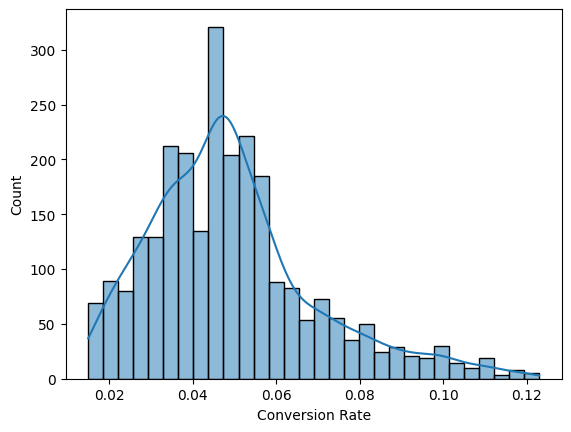

In [474]:

    sns.histplot(
        df["Conversion Rate"].dropna(),
        kde=True,
        bins=30
    )

In [475]:
### This mean imputation changed the shape little bit but this is acceptable 

In [476]:
## There is no Null value in the Conversion Rate and according to kde plot the distribution of data is almost same 
df['Conversion Rate'].isna().sum()

np.int64(0)

In [477]:
df.isna().sum()

Ad_ID                0
Campaign_Name        0
Clicks             112
Impressions         54
Cost                97
Leads               48
Conversions         74
Conversion Rate      0
Sale_Amount        139
Ad_Date              0
Location             0
Device               0
Keyword              0
dtype: int64

In [478]:
## Handling the Sales NULL values 

In [479]:
df[df["Sale_Amount"].isna()]

,Ad_ID,Campaign_Name,Clicks,Impressions,Cost,Leads,Conversions,Conversion Rate,Sale_Amount,Ad_Date,Location,Device,Keyword
34,A1034,Data Analytcis Course,121.0,5610.0,214.96,23.0,8.0,0.066,NaN,2024-11-25,hyderabad,Mobile,data analytics course
59,A1059,Data Analytics Corse,179.0,3025.0,238.81,17.0,3.0,0.017,NaN,2024-11-11,HYDERABAD,mobile,data analitics online
72,A1072,DataAnalyticsCourse,133.0,3728.0,199.13,11.0,10.0,0.075,NaN,2024-11-09,HYDERABAD,Desktop,data analitics online
82,A1082,Data Analytcis Course,149.0,3587.0,217.53,23.0,8.0,0.054,NaN,17-11-2024,hydrebad,Mobile,data analitics online
103,A1103,Data Analytcis Course,119.0,5800.0,221.36,11.0,8.0,0.067,NaN,29-11-2024,hydrebad,Desktop,analytics for data
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2462,A3462,DataAnalyticsCourse,172.0,4441.0,209.18,17.0,10.0,0.043,NaN,2024-11-29,hydrebad,desktop,data analitics online
2484,A3484,Data Anlytics Corse,168.0,5384.0,235.64,28.0,3.0,0.018,NaN,2024-11-16,hyderabad,Mobile,data analytics course
2501,A3501,Data Anlytics Corse,157.0,3164.0,227.73,20.0,3.0,0.034,NaN,20-11-2024,hyderabad,MOBILE,data anaytics training
2508,A3508,Data Analytcis Course,163.0,4813.0,190.77,22.0,8.0,0.049,NaN,2024/11/25,hyderabad,desktop,online data analytic


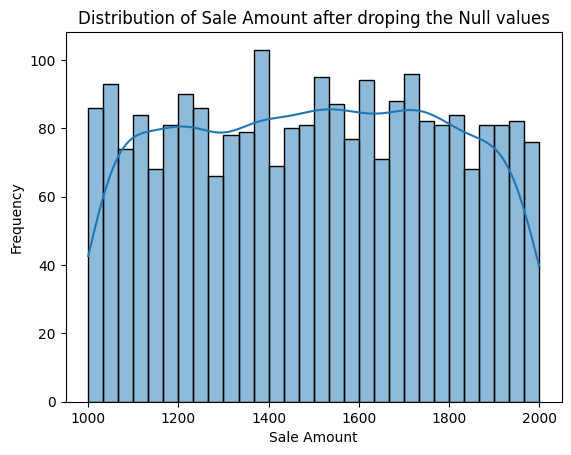

In [480]:
## for filling this we can compute ccampaign_names wise mean of Sale_amount 
df["Sale_Amount"] = (
    df["Sale_Amount"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
)

df["Sale_Amount"] = pd.to_numeric(
    df["Sale_Amount"],
    errors="coerce"
)

sns.histplot(
    df["Sale_Amount"].dropna(),
    kde=True,
    bins=30
)

plt.title("Distribution of Sale Amount after droping the Null values")
plt.xlabel("Sale Amount")
plt.ylabel("Frequency")
plt.show()

In [481]:
## replacing with means
df['Sale_Amount'] = df['Sale_Amount'].replace(r'[\$, ]', '', regex=True)
df['Sale_Amount'] = pd.to_numeric(df['Sale_Amount'], errors='coerce')
aligned_means = df.groupby('Campaign_Name')['Sale_Amount'].transform('mean').round(0)

df['Sale_Amount'] = df['Sale_Amount'].fillna(aligned_means)

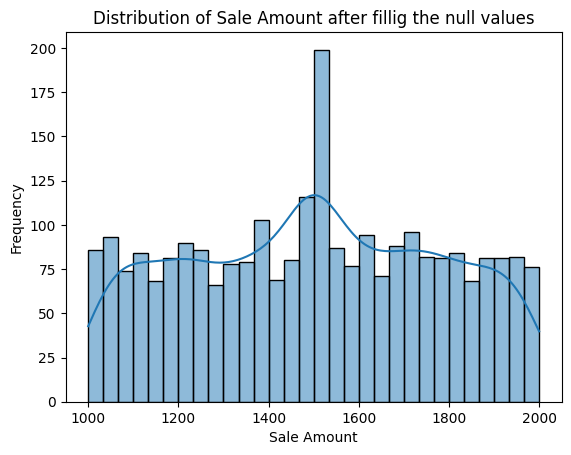

In [482]:
df["Sale_Amount"] = (
    df["Sale_Amount"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
)

df["Sale_Amount"] = pd.to_numeric(
    df["Sale_Amount"],
    errors="coerce"
)

sns.histplot(
    df["Sale_Amount"],
    kde=True,
    bins=30
)

plt.title("Distribution of Sale Amount after fillig the null values")
plt.xlabel("Sale Amount")
plt.ylabel("Frequency")
plt.show()

In [483]:
## The distribution graph is same hence this is also acceptable

In [484]:
df[df['Sale_Amount'].isna()].count()

Ad_ID              0
Campaign_Name      0
Clicks             0
Impressions        0
Cost               0
Leads              0
Conversions        0
Conversion Rate    0
Sale_Amount        0
Ad_Date            0
Location           0
Device             0
Keyword            0
dtype: int64

In [485]:
df.isna().sum()

Ad_ID                0
Campaign_Name        0
Clicks             112
Impressions         54
Cost                97
Leads               48
Conversions         74
Conversion Rate      0
Sale_Amount          0
Ad_Date              0
Location             0
Device               0
Keyword              0
dtype: int64

In [486]:
df[df['Conversions'].isna()]

,Ad_ID,Campaign_Name,Clicks,Impressions,Cost,Leads,Conversions,Conversion Rate,Sale_Amount,Ad_Date,Location,Device,Keyword
148,A1148,Data Analytics Corse,180.0,4326.0,221.67,13.0,NaN,0.046,1427.0,06-11-2024,Hyderbad,TABLET,online data analytic
211,A1211,DataAnalyticsCourse,101.0,3241.0,183.34,24.0,NaN,0.047,1483.0,10-11-2024,Hyderbad,TABLET,data anaytics training
213,A1213,Data Analytics Corse,199.0,5734.0,247.99,18.0,NaN,0.046,1455.0,2024/11/11,hydrebad,DESKTOP,data analitics online
229,A1229,Data Anlytics Corse,165.0,4551.0,185.35,30.0,NaN,0.046,1662.0,2024/11/06,Hyderbad,desktop,data analitics online
233,A1233,Data Anlytics Corse,161.0,5977.0,193.27,24.0,NaN,0.046,1366.0,13-11-2024,Hyderbad,Desktop,online data analytic
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2533,A3533,Data Anlytics Corse,130.0,5340.0,221.95,27.0,NaN,0.046,1488.0,2024/11/02,Hyderbad,tablet,data analitics online
2543,A3543,Data Analytcis Course,158.0,3766.0,222.89,27.0,NaN,0.056,1673.0,2024/11/22,Hyderbad,mobile,learn data analytics
2560,A3560,Data Anlytics Corse,170.0,3401.0,235.70,10.0,NaN,0.046,1047.0,2024/11/15,HYDERABAD,MOBILE,online data analytic
2566,A3566,Data Analytcis Course,160.0,5975.0,212.18,14.0,NaN,0.048,1507.0,2024/11/04,hydrebad,Tablet,data analytics course


In [487]:
## we have a formula for conversion_rate = conversion/clicks 
## we can compute the value of the conversions by conversion_rate * clicksabs


In [488]:
# conversion
df['Conversions'] = df['Conversions'].fillna(df['Conversion Rate']*df['Clicks']).round(1)

In [489]:
df[df['Conversions'].isna()]

,Ad_ID,Campaign_Name,Clicks,Impressions,Cost,Leads,Conversions,Conversion Rate,Sale_Amount,Ad_Date,Location,Device,Keyword
345,A1345,Data Analytcis Course,NaN,3705.0,239.26,25.0,NaN,0.048,1506.0,02-11-2024,HYDERABAD,TABLET,online data analytic
1565,A2565,Data Analytcis Course,NaN,4896.0,207.51,17.0,NaN,0.048,1502.0,2024-11-11,hyderabad,mobile,data analitics online
2479,A3479,Data Analytics Corse,NaN,3699.0,186.22,23.0,NaN,0.046,1218.0,2024-11-23,hydrebad,Tablet,analytics for data


In [490]:
df.isna().sum()

Ad_ID                0
Campaign_Name        0
Clicks             112
Impressions         54
Cost                97
Leads               48
Conversions          3
Conversion Rate      0
Sale_Amount          0
Ad_Date              0
Location             0
Device               0
Keyword              0
dtype: int64

In [491]:
df['Conversions'] = df['Conversions'].fillna(
    df.groupby('Campaign_Name')['Conversions'].transform('mean').round(0)
)

In [492]:
df.isna().sum()

Ad_ID                0
Campaign_Name        0
Clicks             112
Impressions         54
Cost                97
Leads               48
Conversions          0
Conversion Rate      0
Sale_Amount          0
Ad_Date              0
Location             0
Device               0
Keyword              0
dtype: int64

In [493]:
## Handling the clicks in dataset using Conversions/Conversions Rate

In [494]:
## Extracting all the Null values 
df[df['Clicks'].isna()] 

,Ad_ID,Campaign_Name,Clicks,Impressions,Cost,Leads,Conversions,Conversion Rate,Sale_Amount,Ad_Date,Location,Device,Keyword
27,A1027,Data Analytics Corse,NaN,5286.0,234.89,22.0,10.0,0.046,1688.0,2024-11-21,hyderabad,DESKTOP,data anaytics training
32,A1032,Data Analytcis Course,NaN,3872.0,244.38,20.0,4.0,0.048,1041.0,12-11-2024,HYDERABAD,tablet,data analitics online
93,A1093,DataAnalyticsCourse,NaN,5903.0,184.41,23.0,9.0,0.047,1188.0,20-11-2024,Hyderbad,tablet,online data analytic
141,A1141,Data Analytcis Course,NaN,4259.0,182.98,10.0,10.0,0.031,1048.0,16-11-2024,hyderabad,MOBILE,analytics for data
197,A1197,Data Analytcis Course,NaN,5016.0,238.59,26.0,9.0,0.048,1620.0,2024-11-20,Hyderbad,Mobile,data analitics online
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2554,A3554,Data Anlytics Corse,NaN,5852.0,181.96,19.0,4.0,0.046,1816.0,2024/11/22,HYDERABAD,tablet,data analitics online
2571,A3571,DataAnalyticsCourse,NaN,5386.0,220.23,23.0,5.0,0.047,1462.0,08-11-2024,Hyderbad,desktop,data analitics online
2578,A3578,Data Anlytics Corse,NaN,3075.0,239.32,12.0,10.0,0.046,1966.0,2024-11-22,Hyderbad,Mobile,data analytics course
2581,A3581,Data Analytcis Course,NaN,5297.0,NaN,27.0,9.0,0.048,1268.0,23-11-2024,hyderabad,Desktop,data analytics course


In [495]:
df['Clicks'] = df['Clicks'].fillna(df['Conversions']/df['Conversion Rate']).round(1)

In [496]:
df.isna().sum()

Ad_ID               0
Campaign_Name       0
Clicks              0
Impressions        54
Cost               97
Leads              48
Conversions         0
Conversion Rate     0
Sale_Amount         0
Ad_Date             0
Location            0
Device              0
Keyword             0
dtype: int64

In [497]:
## we need to handle the costing 
## one thing that we can do that handling them using interpolation 

In [498]:
## Handling the costing 
## Extract all the null values 
df[df['Cost'].isna()]

,Ad_ID,Campaign_Name,Clicks,Impressions,Cost,Leads,Conversions,Conversion Rate,Sale_Amount,Ad_Date,Location,Device,Keyword
8,A1008,Data Analytics Corse,113.0,5434.0,NaN,27.0,4.0,0.058,1362.0,2024/11/24,Hyderbad,Tablet,data anaytics training
16,A1016,Data Analytcis Course,193.0,5159.0,NaN,15.0,9.0,0.047,1614.0,2024-11-10,hydrebad,Mobile,learn data analytics
19,A1019,Data Analytcis Course,145.0,5278.0,NaN,25.0,6.0,0.041,1516.0,2024-11-05,hyderabad,DESKTOP,data analytics course
24,A1024,DataAnalyticsCourse,87.0,3718.0,NaN,12.0,3.0,0.034,1652.0,20-11-2024,Hyderbad,tablet,learn data analytics
37,A1037,Data Analytcis Course,123.0,5131.0,NaN,19.0,5.0,0.041,1307.0,09-11-2024,hydrebad,MOBILE,learn data analytics
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2497,A3497,Data Anlytics Corse,135.0,4611.0,NaN,17.0,7.0,0.052,1697.0,14-11-2024,hydrebad,Desktop,online data analytic
2522,A3522,Data Analytics Corse,127.0,3682.0,NaN,21.0,9.0,0.071,1384.0,2024-11-22,HYDERABAD,TABLET,data anaytics training
2528,A3528,DataAnalyticsCourse,132.0,5616.0,NaN,28.0,7.0,0.053,1491.0,26-11-2024,hyderabad,desktop,data analitics online
2581,A3581,Data Analytcis Course,187.5,5297.0,NaN,27.0,9.0,0.048,1268.0,23-11-2024,hyderabad,Desktop,data analytics course


In [499]:
## there are almost 97 null values in the cost 
## this is the total percentage of whole data is 4% hence we can drop it 
## and after droping the distribution of data is same again 


In [500]:
df = df.dropna(subset=['Cost'])

In [501]:
df['Cost'].isna().sum()

np.int64(0)

In [502]:
df.isna().sum()

Ad_ID               0
Campaign_Name       0
Clicks              0
Impressions        51
Cost                0
Leads              46
Conversions         0
Conversion Rate     0
Sale_Amount         0
Ad_Date             0
Location            0
Device              0
Keyword             0
dtype: int64

In [503]:
df[df['Impressions'].isna()]


,Ad_ID,Campaign_Name,Clicks,Impressions,Cost,Leads,Conversions,Conversion Rate,Sale_Amount,Ad_Date,Location,Device,Keyword
114,A1114,Data Analytics Corse,91.0,NaN,203.52,NaN,9.0,0.099,1838.0,20-11-2024,hydrebad,DESKTOP,data analytics course
120,A1120,Data Anlytics Corse,117.0,NaN,214.18,29.0,4.0,0.034,1348.0,2024/11/23,hyderabad,MOBILE,learn data analytics
160,A1160,Data Anlytics Corse,160.0,NaN,245.87,11.0,6.0,0.037,1485.0,2024-11-05,Hyderbad,DESKTOP,analytics for data
210,A1210,Data Analytcis Course,199.0,NaN,199.98,15.0,8.0,0.040,1467.0,2024-11-08,HYDERABAD,tablet,data anaytics training
232,A1232,Data Anlytics Corse,101.0,NaN,234.17,29.0,5.0,0.050,1568.0,2024-11-27,hyderabad,mobile,data anaytics training
294,A1294,Data Anlytics Corse,90.0,NaN,249.00,21.0,10.0,0.111,1245.0,19-11-2024,hyderabad,mobile,data analytics course
398,A1398,Data Analytcis Course,163.0,NaN,206.46,14.0,3.0,0.018,1103.0,2024/11/12,HYDERABAD,tablet,learn data analytics
446,A1446,Data Analytcis Course,145.0,NaN,236.03,24.0,8.0,0.055,1220.0,17-11-2024,hydrebad,Desktop,online data analytic
468,A1468,DataAnalyticsCourse,181.0,NaN,208.33,22.0,8.0,0.044,1932.0,2024-11-05,HYDERABAD,Tablet,online data analytic
471,A1471,Data Anlytics Corse,83.0,NaN,229.97,12.0,8.0,0.096,2000.0,30-11-2024,Hyderbad,DESKTOP,analytics for data


In [504]:
df.columns

Index(['Ad_ID', 'Campaign_Name', 'Clicks', 'Impressions', 'Cost', 'Leads',
       'Conversions', 'Conversion Rate', 'Sale_Amount', 'Ad_Date', 'Location',
       'Device', 'Keyword'],
      dtype='object')

In [505]:
## for finding the values of the impressons there is a technique Impression = conversions/ conversion_rate

In [506]:
# Calculate Impressions for missing values
df['Impressions'] = df['Impressions'].fillna(
    (df['Conversions'] / df['Conversion Rate']).round(1)
)

/var/folders/hp/zhxcq53502bctszvjqf2vgq00000gn/T/ipykernel_3190/1955209290.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Impressions'] = df['Impressions'].fillna(


In [507]:
df = df.dropna(subset=['Leads'])

In [508]:
df.isna().sum()

Ad_ID              0
Campaign_Name      0
Clicks             0
Impressions        0
Cost               0
Leads              0
Conversions        0
Conversion Rate    0
Sale_Amount        0
Ad_Date            0
Location           0
Device             0
Keyword            0
dtype: int64

In [510]:
## full data is cleaned pproperly now lets export this 
df.to_csv('cleaned_google _ads.csv',index=False)